In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/customer_segmentation.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1048567, 9)


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


In [2]:
print("Dataset Information:")
print("--------------------")

df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
--------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB

Missing Values:
TransactionID                 0
CustomerID                    0
CustomerDOB                3397
CustGender                 1100
CustLocation          

In [3]:
# Fill missing customer information

df["CustomerDOB"] = df["CustomerDOB"].fillna("Unknown")
df["CustGender"] = df["CustGender"].fillna("Unknown")
df["CustLocation"] = df["CustLocation"].fillna("Unknown")

# Fill missing account balance with median
df["CustAccountBalance"] = df["CustAccountBalance"].fillna(
    df["CustAccountBalance"].median()
)

print("Missing values handled successfully!")

print("\nRemaining Missing Values:")
print(df.isnull().sum())

Missing values handled successfully!

Remaining Missing Values:
TransactionID              0
CustomerID                 0
CustomerDOB                0
CustGender                 0
CustLocation               0
CustAccountBalance         0
TransactionDate            0
TransactionTime            0
TransactionAmount (INR)    0
dtype: int64


In [4]:
customer_data = df.groupby("CustomerID").agg(
    Total_Transactions=("TransactionID", "count"),
    Total_Transaction_Amount=("TransactionAmount (INR)", "sum"),
    Average_Transaction_Amount=("TransactionAmount (INR)", "mean"),
    Account_Balance=("CustAccountBalance", "mean")
).reset_index()

print("Customer-level data created successfully!")
print("Total Customers:", len(customer_data))

customer_data.head()

Customer-level data created successfully!
Total Customers: 884265


,CustomerID,Total_Transactions,Total_Transaction_Amount,Average_Transaction_Amount,Account_Balance
0,C1010011,2,5106.0,2553.0,76340.635
1,C1010012,1,1499.0,1499.0,24204.490
2,C1010014,2,1455.0,727.5,100112.950
3,C1010018,1,30.0,30.0,496.180
4,C1010024,1,5000.0,5000.0,87058.650


In [5]:
features = [
    "Total_Transactions",
    "Total_Transaction_Amount",
    "Average_Transaction_Amount",
    "Account_Balance"
]

X = customer_data[features]

print("Features selected for clustering:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)

Features selected for clustering:
['Total_Transactions', 'Total_Transaction_Amount', 'Average_Transaction_Amount', 'Account_Balance']

Feature shape: (884265, 4)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed successfully!")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed successfully!
Scaled data shape: (884265, 4)


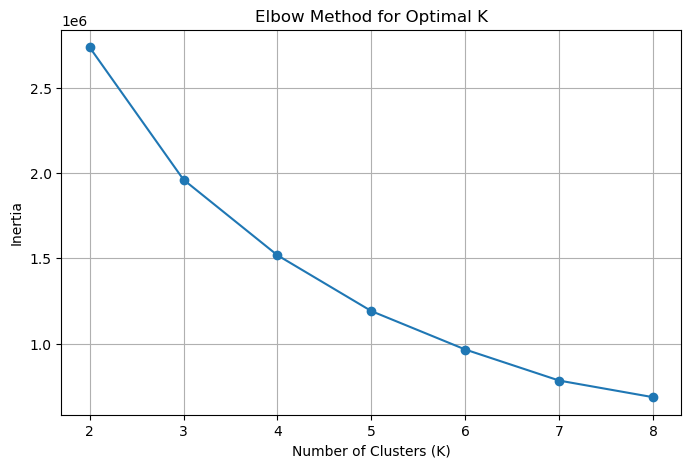

In [7]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(2, 9))
plt.grid(True)
plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means model trained successfully!")
print("\nCluster Distribution:")
print(customer_data["Cluster"].value_counts().sort_index())

K-Means model trained successfully!

Cluster Distribution:
Cluster
0    737223
1    142723
2       129
3      4190
Name: count, dtype: int64


In [9]:
cluster_profile = customer_data.groupby("Cluster")[[
    "Total_Transactions",
    "Total_Transaction_Amount",
    "Average_Transaction_Amount",
    "Account_Balance"
]].mean().round(2)

print("Customer Segment Profile:")
print(cluster_profile)

Customer Segment Profile:
         Total_Transactions  Total_Transaction_Amount  \
Cluster                                                 
0                      1.00                   1268.68   
1                      2.14                   2866.07   
2                      1.12                   9179.79   
3                      1.24                  72853.73   

         Average_Transaction_Amount  Account_Balance  
Cluster                                               
0                           1268.68        105556.66  
1                           1334.79        110908.40  
2                           8719.85      47169021.40  
3                          63387.55        453961.73  


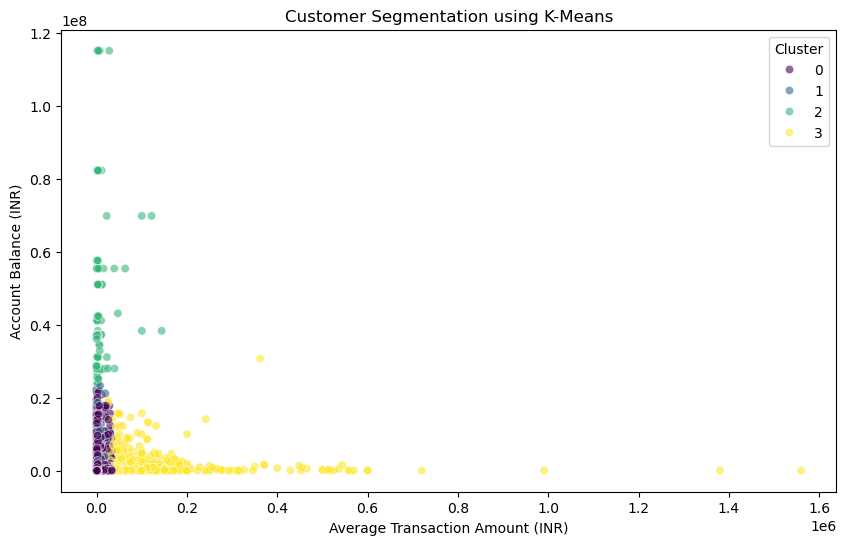

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_data,
    x="Average_Transaction_Amount",
    y="Account_Balance",
    hue="Cluster",
    palette="viridis",
    alpha=0.6
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Average Transaction Amount (INR)")
plt.ylabel("Account Balance (INR)")
plt.legend(title="Cluster")
plt.show()

In [11]:
from sklearn.metrics import silhouette_score

sample_size = 10000

sample_indices = np.random.RandomState(42).choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

silhouette_avg = silhouette_score(
    X_scaled[sample_indices],
    customer_data["Cluster"].iloc[sample_indices]
)

print("Silhouette Score:", round(silhouette_avg, 4))

Silhouette Score: 0.7904


In [12]:
segment_names = {
    0: "Low Activity Customers",
    1: "Regular Customers",
    2: "High Balance Customers",
    3: "High-Value Transaction Customers"
}

customer_data["Segment"] = customer_data["Cluster"].map(segment_names)

print("Customer segment names assigned successfully!")

print("\nSegment Distribution:")
print(customer_data["Segment"].value_counts())

Customer segment names assigned successfully!

Segment Distribution:
Segment
Low Activity Customers              737223
Regular Customers                   142723
High-Value Transaction Customers      4190
High Balance Customers                 129
Name: count, dtype: int64


In [13]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(kmeans, "../models/customer_segmentation_model.pkl")
joblib.dump(scaler, "../models/customer_segmentation_scaler.pkl")

print("Customer segmentation model saved successfully!")
print("Model: models/customer_segmentation_model.pkl")
print("Scaler: models/customer_segmentation_scaler.pkl")

Customer segmentation model saved successfully!
Model: models/customer_segmentation_model.pkl
Scaler: models/customer_segmentation_scaler.pkl


In [14]:
customer_data.to_csv(
    "../data/customer_segments.csv",
    index=False
)

print("Customer segmentation data saved successfully!")
print("File: data/customer_segments.csv")
print("Total Customers:", len(customer_data))
print("Total Segments:", customer_data["Cluster"].nunique())

Customer segmentation data saved successfully!
File: data/customer_segments.csv
Total Customers: 884265
Total Segments: 4
